In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [5]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [6]:
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [7]:
performance.info()


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [8]:
top_return = (
    performance
    .sort_values("return_3yr_pct", ascending=False)
    .head(10)
)

top_return

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High


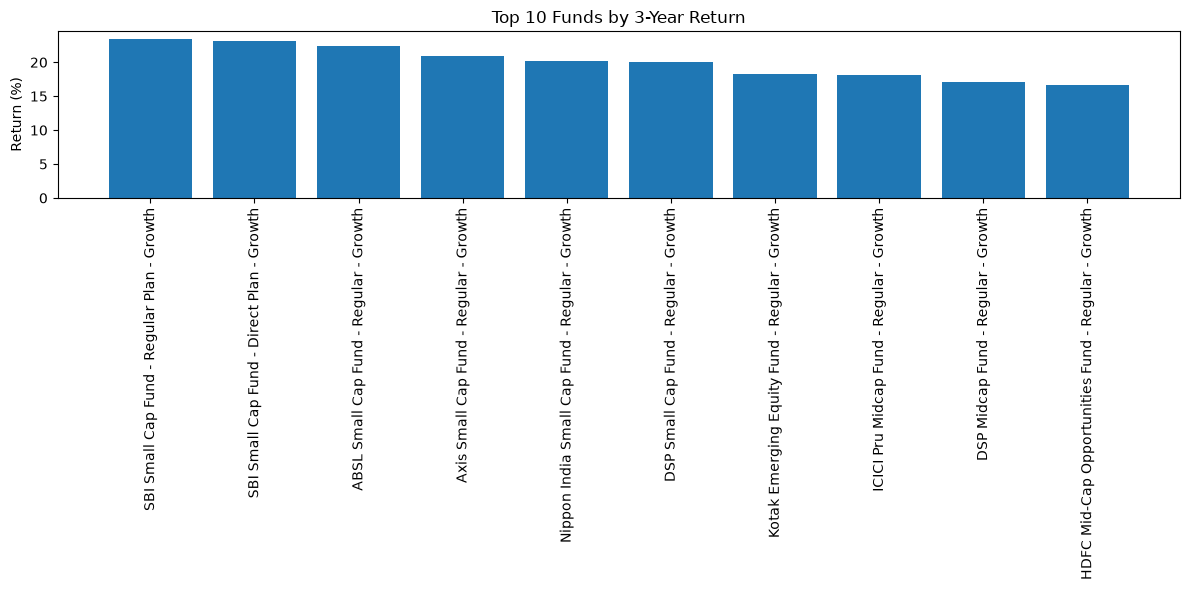

In [9]:
plt.figure(figsize=(12,6))

plt.bar(
    top_return["scheme_name"],
    top_return["return_3yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3-Year Return")

plt.ylabel("Return (%)")

plt.tight_layout()

plt.show()

In [10]:
plt.savefig("../reports/top_3yr_return.png")

<Figure size 640x480 with 0 Axes>

In [11]:
top_sharpe = (
    performance
    .sort_values("sharpe_ratio", ascending=False)
)

top_sharpe.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate


In [12]:
top_sharpe.to_csv(
"../reports/fund_sharpe_ranks.csv",
index=False
)

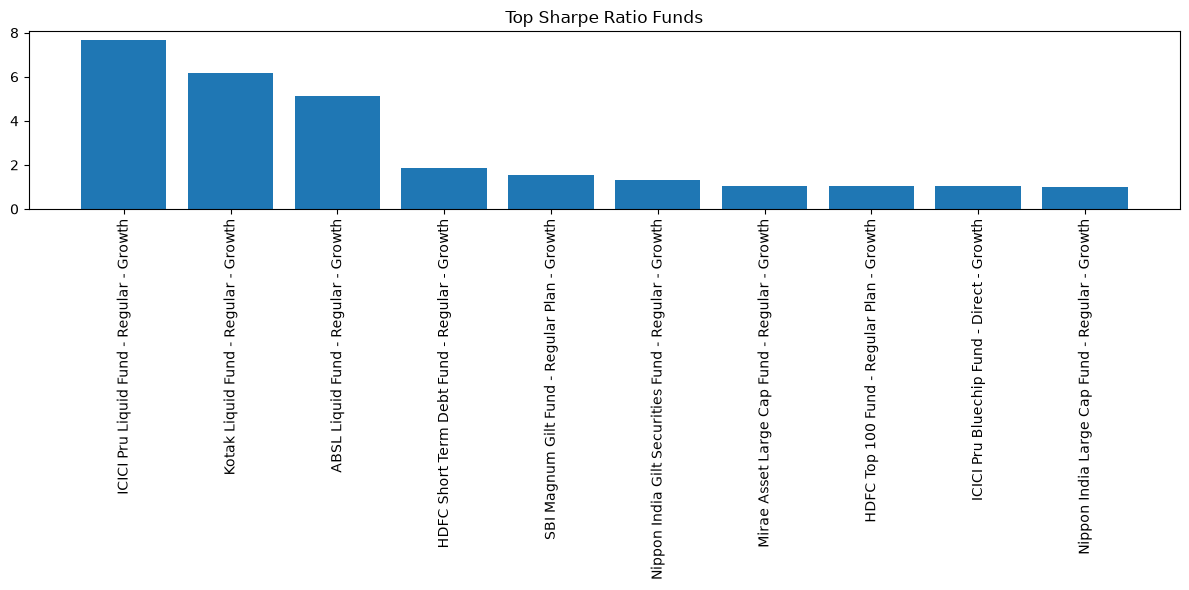

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
top_sharpe.head(10)["scheme_name"],
top_sharpe.head(10)["sharpe_ratio"]
)

plt.xticks(rotation=90)

plt.title("Top Sharpe Ratio Funds")

plt.tight_layout()

plt.show()

In [14]:
alpha_rank = (
performance
.sort_values(
"alpha",
ascending=False
)
)

alpha_rank.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High


In [15]:
alpha_rank.to_csv(
"../reports/alpha_beta.csv",
index=False
)

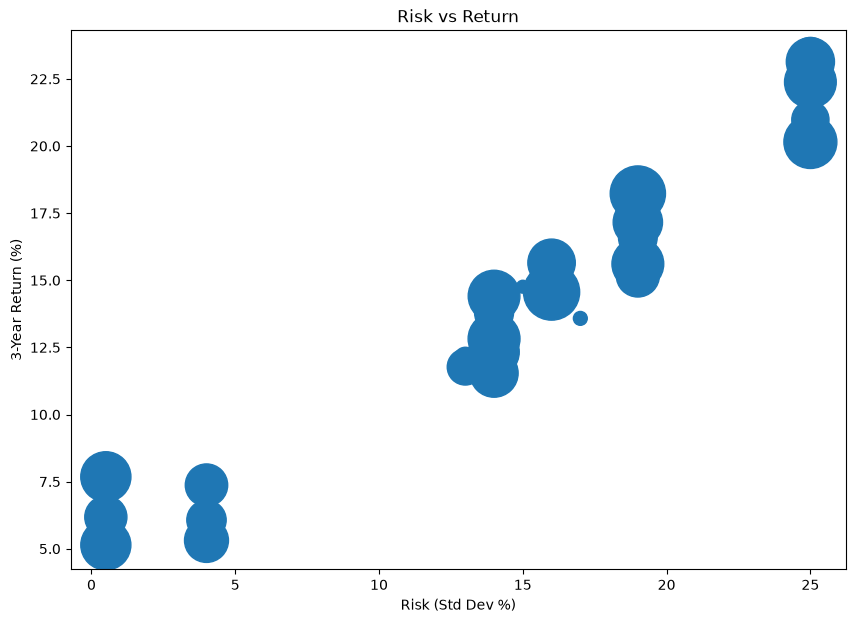

In [16]:
plt.figure(figsize=(10,7))

plt.scatter(
performance["std_dev_ann_pct"],
performance["return_3yr_pct"],
s=performance["aum_crore"]/30
)

plt.xlabel("Risk (Std Dev %)")

plt.ylabel("3-Year Return (%)")

plt.title("Risk vs Return")

plt.show()

In [17]:
drawdown = performance.sort_values(
"max_drawdown_pct"
)

drawdown.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,0.91,0.85,1.25,14.0,-27.54,25803,1.64,4,Moderate
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
18,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Direct,10.14,11.77,12.31,9.97,1.80,1.04,0.91,1.24,13.0,-26.75,20284,0.89,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate


In [18]:
drawdown.to_csv(
"../reports/var_drawdown_summary.csv",
index=False
)

In [19]:
performance.sort_values(
"expense_ratio_pct"
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
16,118633,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF,Large Cap,Direct,14.42,12.33,14.72,10.63,1.70,1.02,0.88,1.48,14.0,-18.14,39475,0.72,3,Moderate
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Large Cap,Direct,13.95,12.14,13.66,10.71,1.43,0.87,0.87,1.54,14.0,-17.40,15866,0.75,4,Moderate
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High


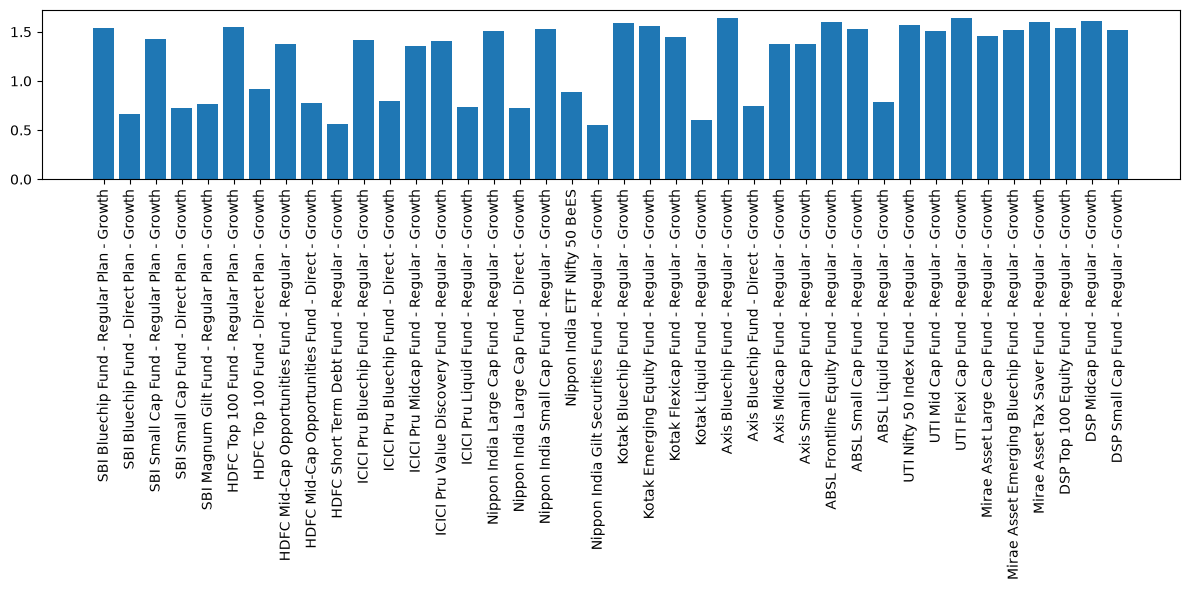

In [20]:
plt.figure(figsize=(12,6))

plt.bar(
performance["scheme_name"],
performance["expense_ratio_pct"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [21]:
performance["Fund Score"] = (

performance["return_3yr_pct"].rank(pct=True)*30 +

performance["sharpe_ratio"].rank(pct=True)*25 +

performance["alpha"].rank(pct=True)*20 +

(1-performance["expense_ratio_pct"].rank(pct=True))*15 +

(1-performance["max_drawdown_pct"].rank(pct=True))*10

)

In [22]:
score = performance.sort_values(
"Fund Score",
ascending=False
)

In [23]:
score.to_csv(
"../reports/fund_scorecard.csv",
index=False
)

In [24]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [25]:
nav.head()

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


In [26]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

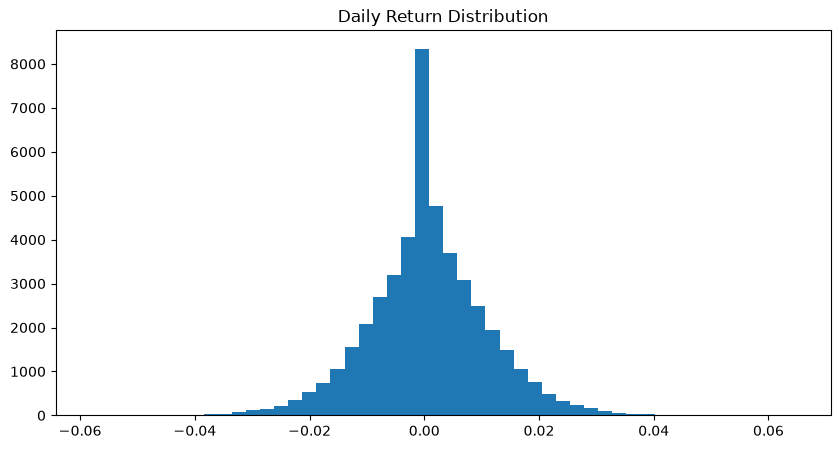

In [27]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

In [28]:
reports/daily_return_distribution.png

NameError: name 'reports' is not defined

In [29]:
def CAGR(start,end,years):

    return (
        (end/start)**(1/years)-1
    )

In [30]:
## 3. Alpha and Beta Analysis

In [31]:
alpha_beta = performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [32]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

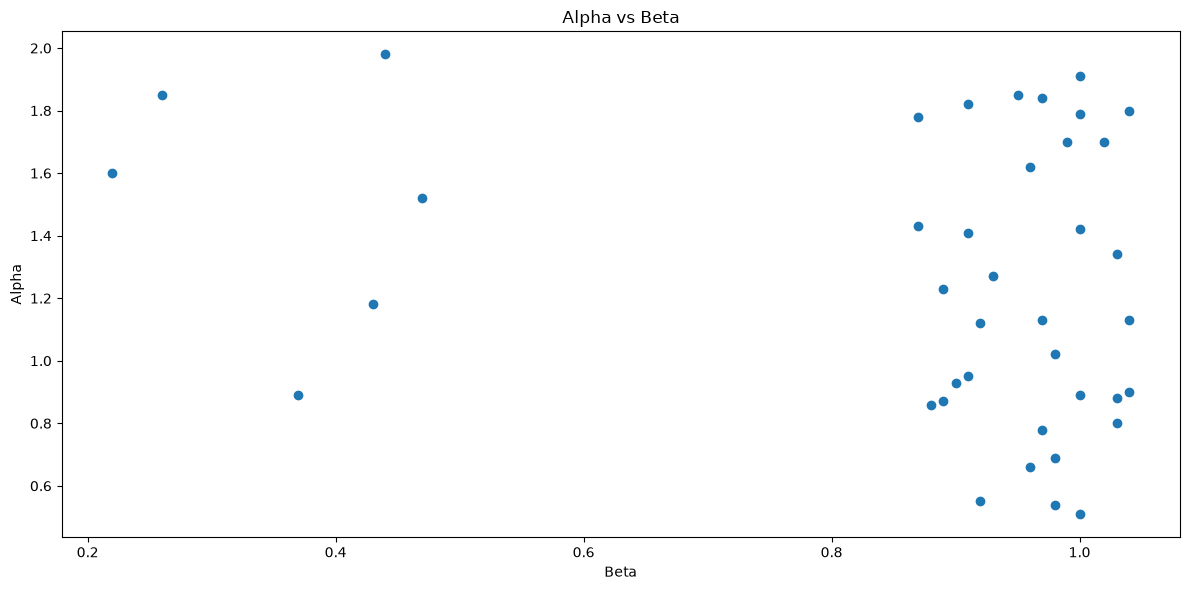

In [33]:
plt.figure(figsize=(12,6))

plt.scatter(
    performance["beta"],
    performance["alpha"]
)

plt.xlabel("Beta")

plt.ylabel("Alpha")

plt.title("Alpha vs Beta")

plt.tight_layout()

plt.savefig("../reports/alpha_beta.png")

plt.show()

In [34]:
## 4. Risk vs Return

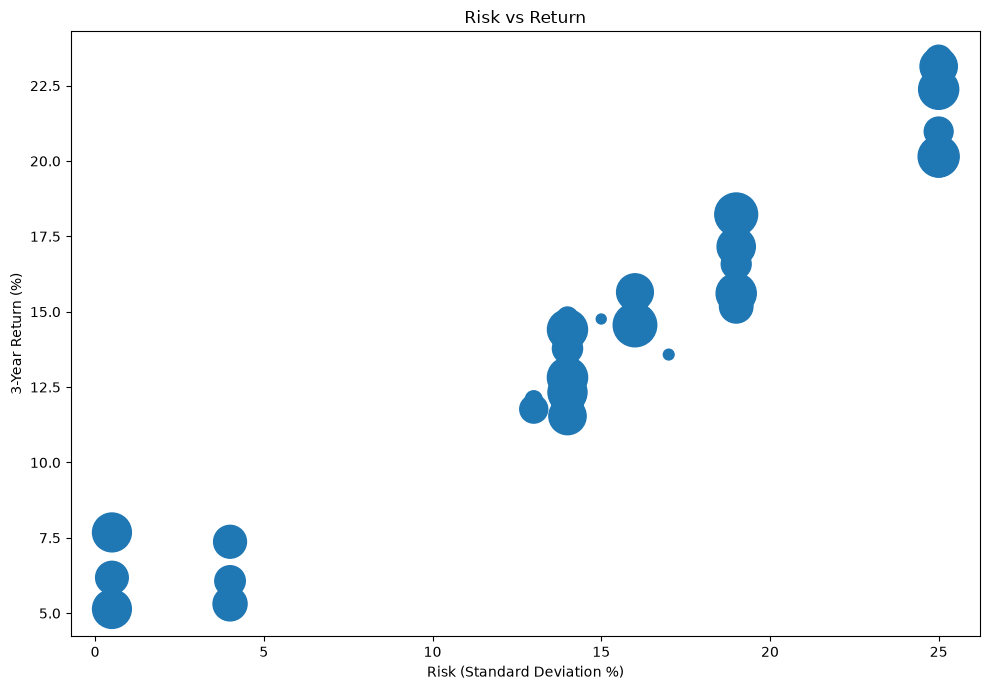

In [35]:
plt.figure(figsize=(10,7))

plt.scatter(

performance["std_dev_ann_pct"],

performance["return_3yr_pct"],

s=performance["aum_crore"]/50

)

plt.xlabel("Risk (Standard Deviation %)")

plt.ylabel("3-Year Return (%)")

plt.title("Risk vs Return")

plt.tight_layout()

plt.savefig("../reports/risk_vs_return.png")

plt.show()

In [36]:
## 5. Maximum Drawdown

In [37]:
drawdown = performance.sort_values(
    "max_drawdown_pct"
)

drawdown.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Fund Score
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate,57.7500
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High,57.8750
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High,51.4375
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High,48.5625
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High,47.0000
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,0.91,0.85,1.25,14.0,-27.54,25803,1.64,4,Moderate,34.4375
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High,51.3125
18,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Direct,10.14,11.77,12.31,9.97,1.80,1.04,0.91,1.24,13.0,-26.75,20284,0.89,5,Moderate,53.4375
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,59.0000
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate,27.6875


In [38]:
drawdown.to_csv(
    "../reports/var_drawdown_summary.csv",
    index=False
)

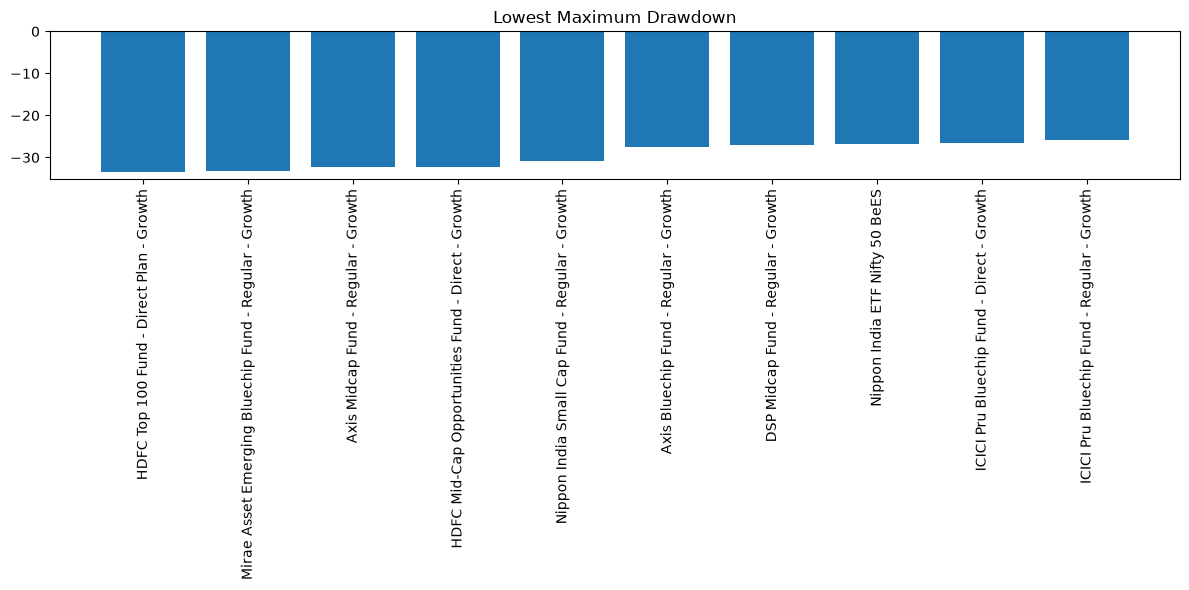

In [39]:
plt.figure(figsize=(12,6))

plt.bar(

drawdown.head(10)["scheme_name"],

drawdown.head(10)["max_drawdown_pct"]

)

plt.xticks(rotation=90)

plt.title("Lowest Maximum Drawdown")

plt.tight_layout()

plt.savefig("../reports/drawdown.png")

plt.show()

In [40]:
## 6. Expense Ratio Analysis

In [41]:
expense = performance.sort_values(
    "expense_ratio_pct"
)

expense.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Fund Score
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,43.7500
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,62.3750
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,55.7500
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,45.1875
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,72.1250
16,118633,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF,Large Cap,Direct,14.42,12.33,14.72,10.63,1.70,1.02,0.88,1.48,14.0,-18.14,39475,0.72,3,Moderate,52.2500
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,61.1250
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Large Cap,Direct,13.95,12.14,13.66,10.71,1.43,0.87,0.87,1.54,14.0,-17.40,15866,0.75,4,Moderate,45.2500
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,50.6250
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High,48.5625


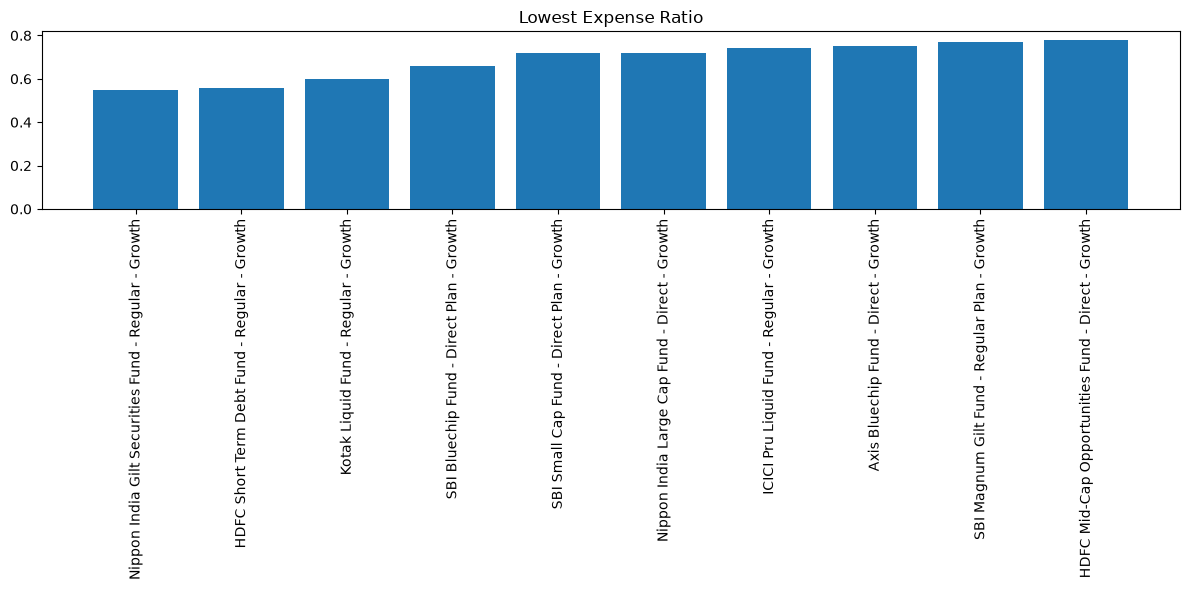

In [42]:
plt.figure(figsize=(12,6))

plt.bar(

expense.head(10)["scheme_name"],

expense.head(10)["expense_ratio_pct"]

)

plt.xticks(rotation=90)

plt.title("Lowest Expense Ratio")

plt.tight_layout()

plt.savefig("../reports/expense_ratio.png")

plt.show()

In [43]:
## 7. Fund Scorecard

In [44]:
performance["Fund Score"]=(

performance["return_3yr_pct"].rank(pct=True)*30+

performance["sharpe_ratio"].rank(pct=True)*25+

performance["alpha"].rank(pct=True)*20+

(1-performance["expense_ratio_pct"].rank(pct=True))*15+

(1-performance["max_drawdown_pct"].rank(pct=True))*10

)

In [45]:
score=performance.sort_values(

"Fund Score",

ascending=False

)

score.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Fund Score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,72.1250
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High,70.8750
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High,69.8750
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High,67.6250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,63.7500
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,63.3125
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,62.3750
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,61.1250
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High,60.3750
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,59.0000


In [46]:
score.to_csv(

"../reports/fund_scorecard.csv",

index=False

)

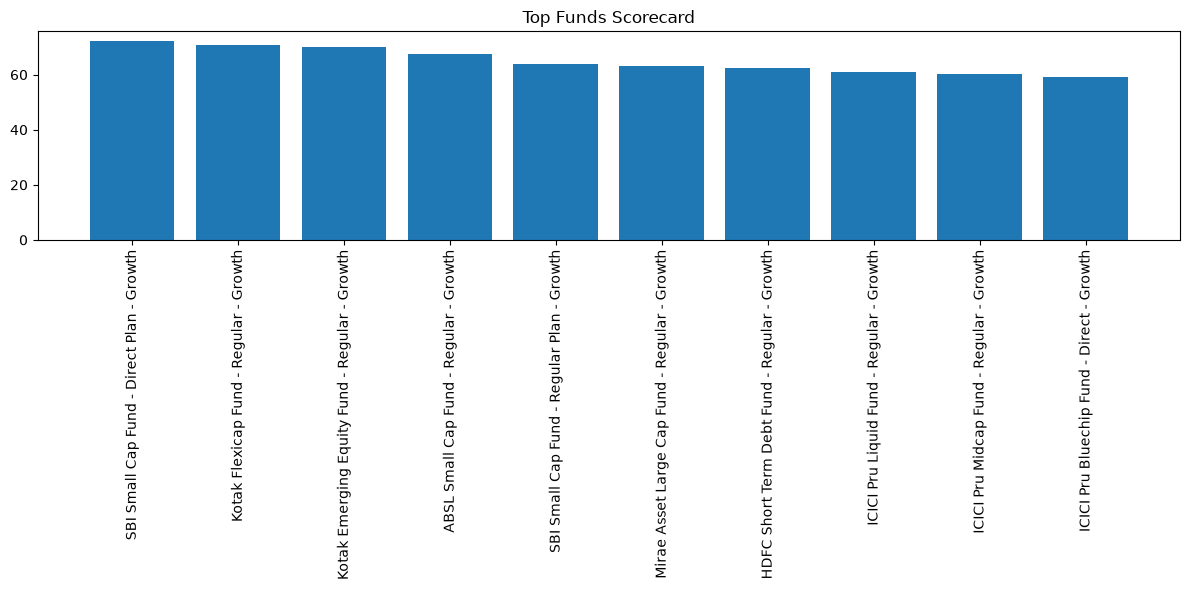

In [47]:
plt.figure(figsize=(12,6))

plt.bar(

score.head(10)["scheme_name"],

score.head(10)["Fund Score"]

)

plt.xticks(rotation=90)

plt.title("Top Funds Scorecard")

plt.tight_layout()

plt.savefig("../reports/fund_scorecard.png")

plt.show()

# Conclusion

### Key Findings

- Identified the top-performing funds based on 3-year returns.
- Ranked funds using Sharpe Ratio for risk-adjusted performance.
- Compared Alpha and Beta values across schemes.
- Visualized the relationship between risk and return.
- Evaluated funds using Maximum Drawdown and Expense Ratio.
- Generated a composite Fund Score to rank overall performance.

The analysis provides investors with a comprehensive view of mutual fund performance by combining return, risk, cost, and consistency metrics.